# Inferência após seleção em bandits gaussianos

este notebook executa a parte 1 do trabalho: comparar políticas de alocação em um bandit gaussiano com cinco braços sob o caso nulo, isto é, com todas as médias verdadeiras iguais a zero.

após cada experimento, selecionar o braço com maior média amostral final, construir o intervalo ingênuo de 95% e estimar a cobertura empírica por política.

## Plano da análise

1. simular recompensas gaussianas com variância conhecida.
2. comparar alocação uniforme aleatória, greedy, ucb e thompson sampling.
3. calcular a média amostral de cada braço ao final de cada replicação.
4. selecionar o braço com maior média amostral.
5. construir o intervalo ingênuo como se o braço tivesse sido escolhido antes dos dados.
6. estimar a cobertura empírica e visualizar a distribuição de $\hat{\mu}_{\hat{a}}$.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

# localizar raiz do projeto
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# adicionar src ao caminho quando o pacote ainda não estiver instalado
sys.path.append(str(PROJECT_ROOT / "src"))

# definir pastas de saída
DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"

# criar pastas quando necessário
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
from bandit_inference.analysis import (
    build_allocation_long,
    build_selected_arm_frequency,
    summarize_by_policy,
)
from bandit_inference.simulation import ExperimentConfig, run_many_experiments
from bandit_inference.visualization import (
    plot_allocation_distribution,
    plot_coverage,
    plot_selected_arm_frequency,
    plot_selected_mean_distribution,
    plot_selected_n_vs_mean,
    save_figure,
    set_plot_theme,
)

c:\Users\joaop\OneDrive\Documents\UFSCar\10º SEMESTRE\LEA\bandits-lea\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configurar experimento


In [3]:
# definir parâmetros principais do experimento
config = ExperimentConfig(
    n_arms=5,
    horizon=1000,
    n_replications=2000,
    sigma=1.0,
    seed=6,
)

config

ExperimentConfig(n_arms=5, horizon=1000, n_replications=2000, sigma=1.0, seed=6, true_means=array([0., 0., 0., 0., 0.]), ci_z_value=1.96, ucb_exploration=2.0, thompson_prior_mean=0.0, thompson_prior_var=10.0)

## Executar simulações

Cada linha da tabela final representa uma política em uma replicação independente.

In [4]:
# executar políticas de alocação
results = run_many_experiments(config=config, progress=True)

# visualizar primeiras linhas
results.head()

simular replicações: 100%|██████████| 2000/2000 [07:25<00:00,  4.49it/s]


,replication,policy,selected_arm,selected_n,selected_mean,selected_true_mean,ci_lower,ci_upper,ci_half_width,covered,...,mean_arm_2,n_arm_3,prop_arm_3,mean_arm_3,n_arm_4,prop_arm_4,mean_arm_4,n_arm_5,prop_arm_5,mean_arm_5
0,0,aleatória uniforme,3,184,0.049339,0.0,-0.095155,0.193832,0.144493,1,...,-0.125886,184,0.184,0.049339,193,0.193,-0.017974,213,0.213,-0.063532
1,0,greedy,2,987,0.035006,0.0,-0.027381,0.097394,0.062387,1,...,0.035006,1,0.001,-0.192024,1,0.001,-1.720116,10,0.010,0.010714
2,0,ucb,2,308,0.028277,0.0,-0.083405,0.139958,0.111681,1,...,0.028277,255,0.255,-0.018375,175,0.175,-0.079210,28,0.028,-0.709770
3,0,thompson sampling,4,366,0.032588,0.0,-0.069863,0.135039,0.102451,1,...,-0.032997,33,0.033,-0.336527,366,0.366,0.032588,67,0.067,-0.207092
4,1,aleatória uniforme,5,196,0.215450,0.0,0.075450,0.355450,0.140000,0,...,0.007202,212,0.212,-0.083584,209,0.209,-0.070103,196,0.196,0.215450


In [5]:
# salvar resultados brutos para reprodutibilidade
try:
    results.to_parquet(DATA_DIR / "simulation_results.parquet", index=False)
except ImportError:
    print("pyarrow não encontrado; salvar apenas em csv")

results.to_csv(DATA_DIR / "simulation_results.csv", index=False)

pyarrow não encontrado; salvar apenas em csv


## Resumir cobertura e viés de seleção

Vamos comparar a cobertura empírica com a cobertura nominal de 95%. observar também a média de $\hat{\mu}_{\hat{a}}$

In [6]:
# calcular tabela resumo por política
summary = summarize_by_policy(results)

# salvar tabela para usar no relatório
summary.to_csv(TABLE_DIR / "summary_by_policy.csv", index=False)
summary

,policy,n_replications,empirical_coverage,selected_mean_average,selected_mean_sd,selected_n_average,ci_half_width_average,average_reward,coverage_se
0,aleatória uniforme,2000,0.8905,0.081470,0.046438,199.5390,0.138966,0.000081,0.006982
1,greedy,2000,0.9540,0.005515,0.032456,966.0760,0.063532,-0.000030,0.004684
2,ucb,2000,0.9230,0.058348,0.036252,293.1995,0.115428,-0.000683,0.005961
3,thompson sampling,2000,0.9150,0.049881,0.036424,368.6025,0.108430,0.000532,0.006236


## Visualizar cobertura empírica


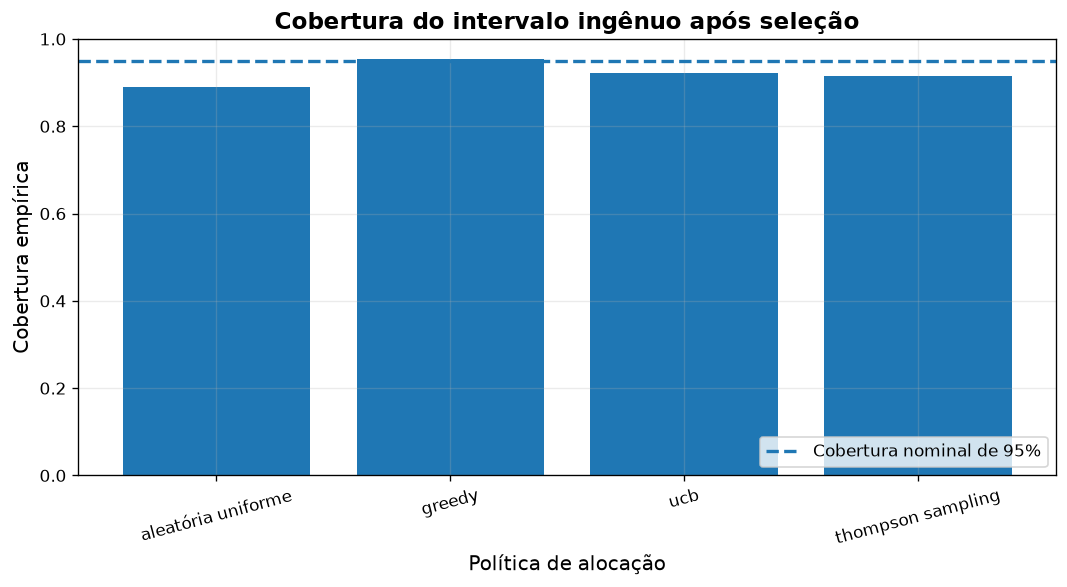

In [7]:
# configurar tema visual
set_plot_theme()

# criar e salvar figura de cobertura
ax = plot_coverage(results)
save_figure(FIGURE_DIR / "coverage_by_policy.png")
plt.show()

## Visualizar distribuição da média selecionada


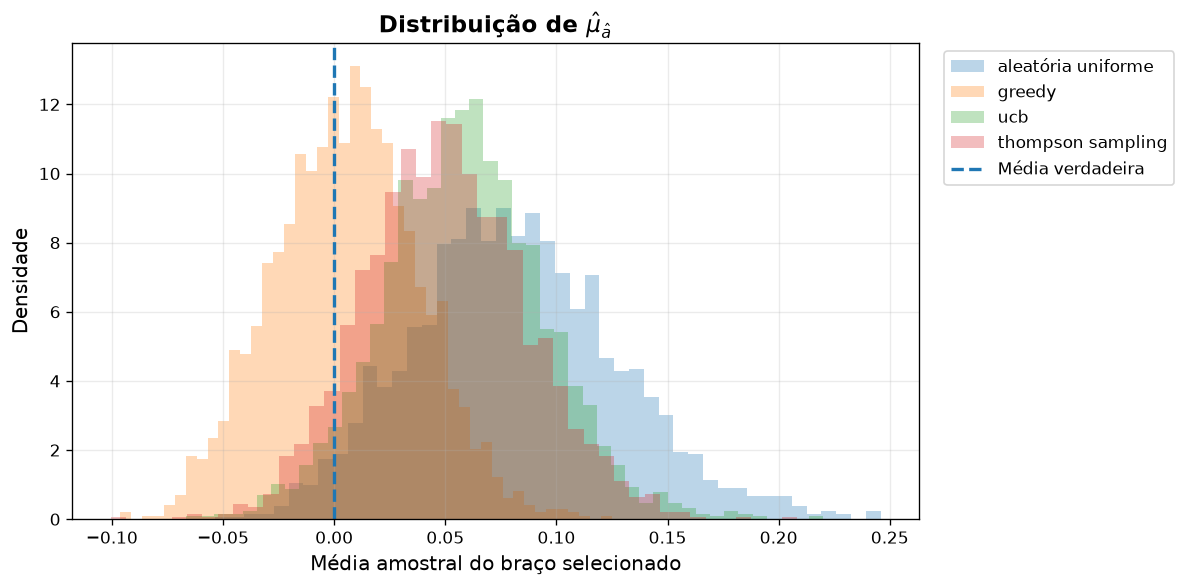

In [8]:
# criar e salvar figura da distribuição da média selecionada
ax = plot_selected_mean_distribution(results)
save_figure(FIGURE_DIR / "selected_mean_distribution.png")
plt.show()

## Visualizar padrão de alocação

Comparar como cada política distribui o orçamento experimental entre os braços.

TypeError: Axes.text() missing 1 required positional argument: 's'

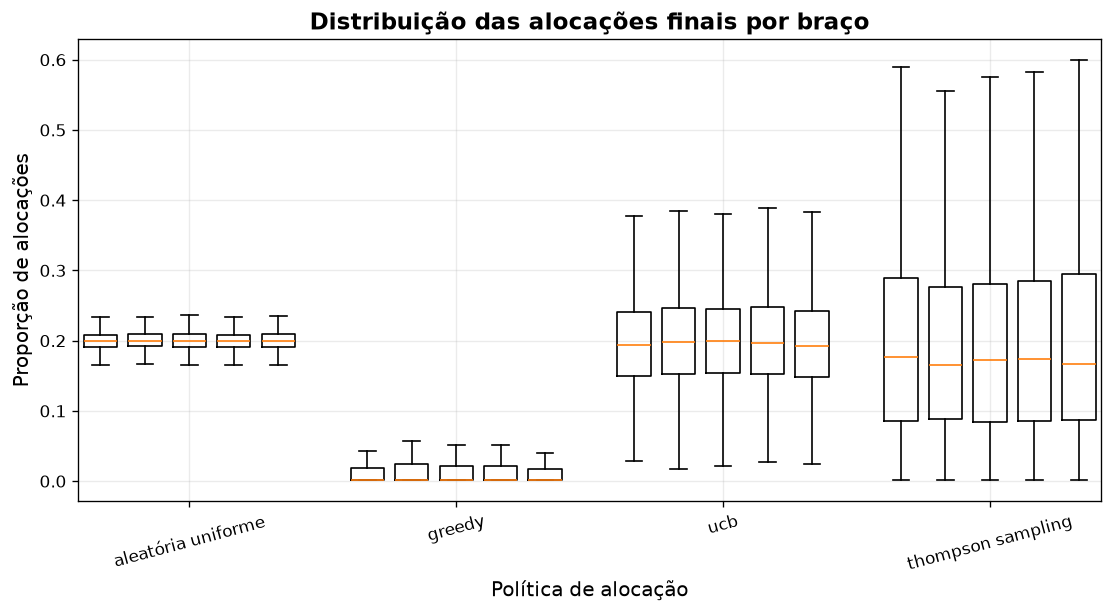

In [10]:
# criar e salvar figura das proporções de alocação
ax = plot_allocation_distribution(results)
save_figure(FIGURE_DIR / "allocation_distribution.png")
plt.show()

## Visualizar frequência do braço selecionado

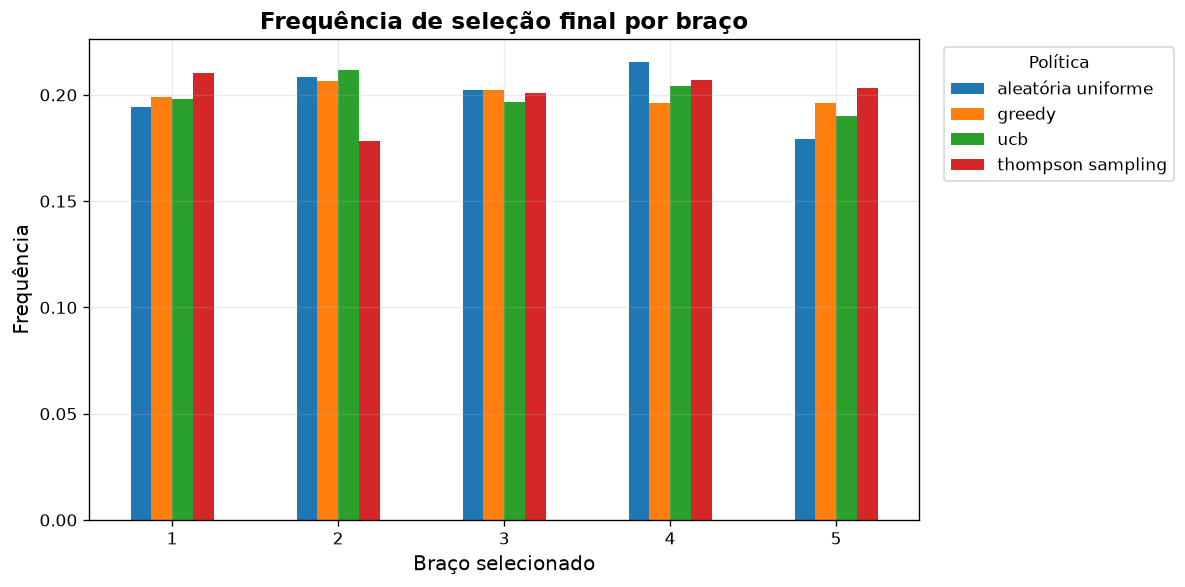

In [11]:
# criar e salvar figura da frequência de seleção
ax = plot_selected_arm_frequency(results)
save_figure(FIGURE_DIR / "selected_arm_frequency.png")
plt.show()

## Relacionar tamanho amostral e média selecionada

Avaliar se políticas adaptativas concentram amostras no braço que parece melhor e como isso altera a variabilidade da média selecionada.

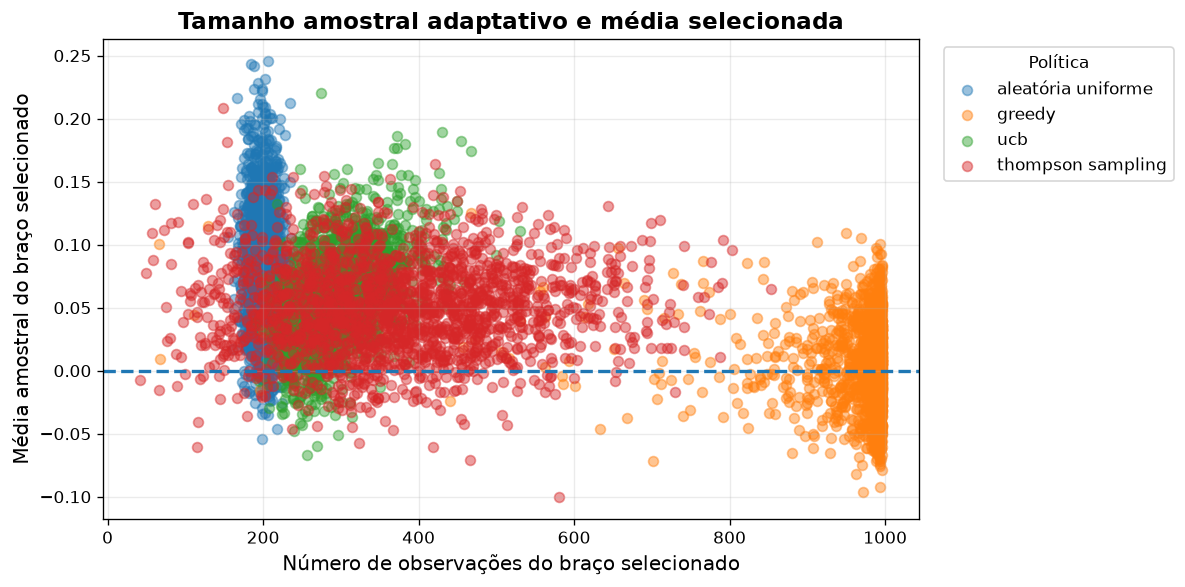

In [12]:
# criar e salvar figura da relação entre tamanho amostral e média selecionada
ax = plot_selected_n_vs_mean(results)
save_figure(FIGURE_DIR / "selected_n_vs_mean.png")
plt.show()

## Tabelas auxiliares para interpretação


In [13]:
# construir tabela longa de alocações
allocation_long = build_allocation_long(results)
allocation_long.head()

,replication,policy,arm,allocation_proportion
0,0,aleatória uniforme,1,0.205
1,0,aleatória uniforme,2,0.205
2,0,aleatória uniforme,3,0.184
3,0,aleatória uniforme,4,0.193
4,0,aleatória uniforme,5,0.213


In [14]:
# calcular frequência de seleção final dos braços
selected_frequency = build_selected_arm_frequency(results)
selected_frequency

,policy,selected_arm,count,frequency
0,aleatória uniforme,1,389,0.1945
1,aleatória uniforme,2,417,0.2085
2,aleatória uniforme,3,405,0.2025
3,aleatória uniforme,4,431,0.2155
4,aleatória uniforme,5,358,0.1790
5,greedy,1,398,0.1990
6,greedy,2,413,0.2065
7,greedy,3,405,0.2025
8,greedy,4,392,0.1960
9,greedy,5,392,0.1960


## Salvar versões arredondadas para o relatório


In [15]:
# arredondar tabela resumo
summary_report = summary.copy()
numeric_columns = summary_report.select_dtypes(include="number").columns
summary_report[numeric_columns] = summary_report[numeric_columns].round(4)

# salvar tabela arredondada
summary_report.to_csv(TABLE_DIR / "summary_by_policy_rounded.csv", index=False)
summary_report

,policy,n_replications,empirical_coverage,selected_mean_average,selected_mean_sd,selected_n_average,ci_half_width_average,average_reward,coverage_se
0,aleatória uniforme,2000,0.8905,0.0815,0.0464,199.5390,0.1390,0.0001,0.0070
1,greedy,2000,0.9540,0.0055,0.0325,966.0760,0.0635,-0.0000,0.0047
2,ucb,2000,0.9230,0.0583,0.0363,293.1995,0.1154,-0.0007,0.0060
3,thompson sampling,2000,0.9150,0.0499,0.0364,368.6025,0.1084,0.0005,0.0062
